# ผู้ส่ง
## นายรัชพล สม่าหลี รหัสเข้าแข่ง 600659


ต้นฉบับ:

https://colab.research.google.com/drive/1_RiPTGk5mrdFb4XgS-XcmGxDXAq7-Vd_?usp=sharing

# Methodology
- Model : HoogBERTa
- วิธีสร้างโมเดล : Fine-Tuning
- พารามิเตอร์ https://arxiv.org/pdf/2101.09635
- เลือกโมเดลจาก Macro F1

In [ ]:
import sys
!{sys.executable} -m pip install -q --root-user-action=ignore transformers datasets scikit-learn matplotlib seaborn seqeval sentencepiece tiktoken protobuf "accelerate>=1.1.0"


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import warnings
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForTokenClassification,
    TrainingArguments, Trainer, DataCollatorForTokenClassification
)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# 1. เตรียมข้อมูลเข้าโมเดล HoogBERTa

In [ ]:
# โหลด dataset จากโฟลเดอร์ในเครื่อง
def load_lst20_local(split_dir):
    data = []

    # ถ้าไม่เจอโฟลเดอร์ ก็คืน dataset ว่าง
    if not os.path.exists(split_dir):
        print(f"Directory not found: {split_dir}")
        return Dataset.from_list([])

    # วนอ่านทุกไฟล์ในโฟลเดอร์
    for filename in os.listdir(split_dir):
        # ใช้เฉพาะไฟล์ .txt และข้ามไฟล์แปลกๆ ที่ไม่เกี่ยว
        if not filename.endswith('.txt') or filename.startswith('._'):
            continue

        filepath = os.path.join(split_dir, filename)

        with open(filepath, 'r', encoding='utf-8') as f:
            tokens = []

            for line in f:
                # ตัดช่องว่างหัวท้ายออกก่อน
                line = line.strip()

                # ถ้าบรรทัดว่าง แปลว่าจบ 1 ประโยคแล้ว
                if line == '':
                    if tokens:
                        data.append({'tokens': tokens})
                        tokens = []

                else:
                    # แต่ละบรรทัดของ LST20 มีหลายคอลัมน์
                    # ตรงนี้เอาแค่คอลัมน์แรก ซึ่งก็คือคำ
                    parts = line.split('	')
                    if len(parts) > 0:
                        word = parts[0]
                        tokens.append(word)

            # เผื่อไฟล์จบแต่ยังมีประโยคค้างอยู่
            if tokens:
                data.append({'tokens': tokens})

    return Dataset.from_list(data)


print("Loading LST20 from Local Folder...")

base_train_dir = "data/LST20_Corpus/train"
base_eval_dir = "data/LST20_Corpus/eval"

train_dataset = load_lst20_local(base_train_dir)
val_dataset = load_lst20_local(base_eval_dir)

print(f"Loaded {len(train_dataset)} sentences for Training.")
print(f"Loaded {len(val_dataset)} sentences for Validation.")


# แปลงจากระดับคำ ให้กลายเป็นระดับตัวอักษร
def convert_to_char_level(example):
    words = example['tokens']
    char_tokens = []
    char_labels = []

    for word in words:
        if len(word) == 0:
            continue

        # ถ้าเป็นช่องว่าง เครื่องหมายพิเศษ หรือ token ที่ไม่อยากใช้เป็นคำปกติ
        # จะให้ label เป็น O
        if word.isspace() or word == '_' or '<' in word:
            for c in word:
                char_tokens.append(c)
                char_labels.append('O')

        else:
            # ถ้าคำยาวแค่ 1 ตัวอักษร
            # ให้มองว่าเป็นต้นคำเลย
            if len(word) == 1:
                char_tokens.append(word[0])
                char_labels.append('B_WORD')

            else:
                # ตัวแรกของคำ
                char_tokens.append(word[0])
                char_labels.append('B_WORD')

                # ตัวกลางของคำ
                for c in word[1:-1]:
                    char_tokens.append(c)
                    char_labels.append('I_WORD')

                # ตัวท้ายของคำ
                char_tokens.append(word[-1])
                char_labels.append('E_WORD')

    return {
        "char_tokens": char_tokens,
        "char_labels": char_labels
    }


print("Converting local dataset to character level format...")

# แปลงชุด train เป็นระดับตัวอักษร
train_ds = train_dataset.map(convert_to_char_level)

# แปลงชุด validation เป็นระดับตัวอักษร
val_ds = val_dataset.map(convert_to_char_level)

Loading LST20 from Local Folder...
Loaded 63310 sentences for Training.
Loaded 5620 sentences for Validation.
Converting local dataset to character level format...


Map:   0%|          | 0/63310 [00:00<?, ? examples/s]

Map:   0%|          | 0/5620 [00:00<?, ? examples/s]

In [ ]:
# สร้าง label และ mapping ระหว่างชื่อ label กับตัวเลข
unique_labels = ['B_WORD', 'I_WORD', 'E_WORD', 'O']

# แปลง label → ตัวเลข (ใช้ตอน train)
label2id = {label: i for i, label in enumerate(unique_labels)}

# แปลงตัวเลข → label (ใช้ตอนแปลผลลัพธ์)
id2label = {i: label for label, i in label2id.items()}


# โหลด tokenizer ของ HoogBERTa
model_name = "lst-nectec/HoogBERTa"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)


def tokenize_and_align_labels(examples):
    # เอา char_tokens ไป tokenize ให้ตรงกับ format ของโมเดล

    tokenized_inputs = tokenizer(
        examples["char_tokens"],
        truncation=True,
        padding=False,
        max_length=400,
        is_split_into_words=True
    )

    labels = []

    # วนทีละ sample
    for i, label in enumerate(examples["char_labels"]):
        # word_ids จะบอกว่า token นี้มาจากตำแหน่งไหนของ input เดิม
        word_ids = tokenized_inputs.word_ids(batch_index=i)

        previous_word_idx = None
        label_ids = []

        for word_idx in word_ids:
            # ถ้าเป็น special token เช่น [CLS], [SEP]
            # ไม่ต้องเอาไปคิด loss
            if word_idx is None:
                label_ids.append(-100)

            # ถ้าเป็น token ใหม่ของตัวอักษรนั้น
            elif word_idx != previous_word_idx:
                label_ids.append(label2id[label[word_idx]])

            # ถ้า tokenizer แยก token เพิ่มจากตัวอักษรเดียวกัน
            # ให้ใช้ label เดิม
            else:
                label_ids.append(label2id[label[word_idx]])

            previous_word_idx = word_idx

        labels.append(label_ids)

    tokenized_inputs["labels"] = labels
    return tokenized_inputs


print("Tokenizing and aligning labels...")

# แปลง train dataset ให้อยู่ในรูปที่โมเดลใช้ได้
tokenized_train = train_ds.map(tokenize_and_align_labels, batched=True)

# แปลง validation dataset
tokenized_val = val_ds.map(tokenize_and_align_labels, batched=True)

Tokenizing and aligning labels...


Map:   0%|          | 0/63310 [00:00<?, ? examples/s]

Map:   0%|          | 0/5620 [00:00<?, ? examples/s]

In [ ]:
from sklearn.metrics import f1_score

def compute_metrics(eval_preds):
    # ฟังก์ชันนี้เอาไว้ประเมินว่าโมเดลทำนายดีแค่ไหน

    logits, labels = eval_preds

    # เลือกคลาสที่โมเดลทำนายได้ดีที่สุดในแต่ละตำแหน่ง
    predictions = np.argmax(logits, axis=2)

    # ตัดตำแหน่งที่เป็น padding (-100) ออก
    true_labels = [
        [l for l in label if l != -100]
        for label in labels
    ]

    true_predictions = [
        [p for (p, l) in zip(prediction, label) if l != -100]
        for prediction, label in zip(predictions, labels)
    ]

    # flatten จาก list ซ้อน ให้เป็น list เดียว
    flat_true = [item for sublist in true_labels for item in sublist]
    flat_preds = [item for sublist in true_predictions for item in sublist]

    # คำนวณคะแนน Macro F1
    # ให้ความสำคัญทุก class เท่ากัน
    macro_f1 = f1_score(flat_true, flat_preds, average='macro')

    return {"macro_f1": macro_f1}

# 2. โหลดและเทรนโมเดล

In [ ]:
# โหลดโมเดลสำหรับงาน token classification
model = AutoModelForTokenClassification.from_pretrained(
    model_name,
    num_labels=len(unique_labels),
    id2label=id2label,
    label2id=label2id
)

# ตั้งค่าการ train
training_args = TrainingArguments(
    output_dir="./results",

    # ประเมินผลทุกจบ 1 epoch
    eval_strategy="epoch",

    # เซฟโมเดลทุกจบ 1 epoch
    save_strategy="epoch",

    # learning rate ที่ใช้ตอน train
    learning_rate=3e-5,

    # batch size ของ train และ validation
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    # จำนวนรอบที่ train
    num_train_epochs=6.0,

    # ลด overfitting เล็กน้อย
    weight_decay=0.01,

    # ช่วงแรกค่อยๆ เพิ่ม learning rate
    warmup_ratio=0.1,

    # ใช้ fp16 เพื่อให้ train เร็วขึ้นและใช้ memory น้อยลง
    fp16=True,

    # หลัง train เสร็จ ให้ดึงโมเดลที่ดีที่สุดกลับมาใช้
    load_best_model_at_end=True,

    # ใช้ macro_f1 เป็นตัวตัดสินว่าโมเดลไหนดีสุด
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    # แสดง log ทุก 100 step
    logging_steps=100
)

# ช่วยจัด batch ให้เหมาะกับงาน token classification
data_collator = DataCollatorForTokenClassification(tokenizer)

# รวมทุกอย่างเข้าด้วยกันใน Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Starting training...")
trainer.train()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForTokenClassification LOAD REPORT from: lst-nectec/HoogBERTa
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.bias                 | MISSING    | 
classifier.weight               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Starting training...


Epoch,Training Loss,Validation Loss,Macro F1
1,0.054998,0.048055,0.986456
2,0.038313,0.036048,0.989750
3,0.030104,0.033184,0.990545
4,0.025149,0.031073,0.990696
5,0.021876,0.029990,0.991380
6,0.019052,0.030415,0.991404


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=11874, training_loss=0.053079919068524585, metrics={'train_runtime': 1520.587, 'train_samples_per_second': 249.811, 'train_steps_per_second': 7.809, 'total_flos': 7.511903971595482e+16, 'train_loss': 0.053079919068524585, 'epoch': 6.0})

Evaluating on Validation Set...



Classification Report:

              precision    recall  f1-score   support

      B_WORD     0.9868    0.9898    0.9883    196438
      E_WORD     0.9862    0.9897    0.9880    188963
      I_WORD     0.9922    0.9897    0.9909    496315
           O     0.9987    0.9982    0.9984     38935

    accuracy                         0.9901    920651
   macro avg     0.9910    0.9918    0.9914    920651
weighted avg     0.9901    0.9901    0.9901    920651



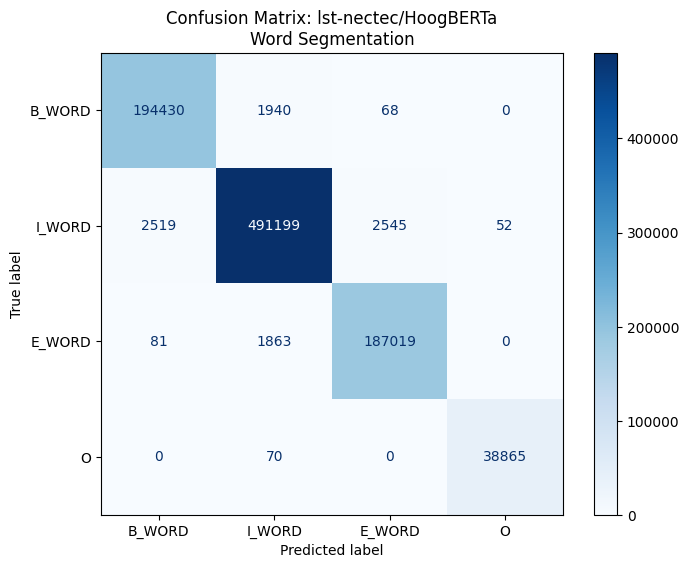

In [ ]:
# ประเมินผลบน validation set
print("Evaluating on Validation Set...")

predictions, labels, _ = trainer.predict(tokenized_val)

# เลือกคลาสที่โมเดลทำนายได้ดีที่สุดในแต่ละตำแหน่ง
preds = np.argmax(predictions, axis=2)

# แปลงค่าที่โมเดลทำนายจากเลขกลับเป็นชื่อ label
# และตัดตำแหน่งที่เป็น padding ออก
true_predictions = [
    [unique_labels[p] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(preds, labels)
]

# แปลง label จริงจากเลขกลับเป็นชื่อ label
# และตัด padding ออกเหมือนกัน
true_labels = [
    [unique_labels[l] for (p, l) in zip(prediction, label) if l != -100]
    for prediction, label in zip(preds, labels)
]

# รวมจากหลายประโยคให้เป็น list เดียว
flat_true = [item for sublist in true_labels for item in sublist]
flat_preds = [item for sublist in true_predictions for item in sublist]

print("\nClassification Report:\n")

# แสดงผลวัดละเอียดของแต่ละ class
print(classification_report(flat_true, flat_preds, digits=4))

# สร้าง confusion matrix เพื่อดูว่าคลาสไหนสับสนกับคลาสไหน
cm = confusion_matrix(flat_true, flat_preds, labels=unique_labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=unique_labels
)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap="Blues", ax=ax, values_format='d')

plt.title(f"Confusion Matrix: {model_name}\nWord Segmentation")
plt.show()

# 3 สร้าง Submission

In [ ]:
# สร้าง submission จากไฟล์ ws_test.txt
# ใช้วิธี sliding window และไม่ให้โมเดลเลือก O ตอนส่งคำตอบ
test_file_path = "data/additional given/super-ai-engineer-ss-6-word-segmentation (1)/ws_test.txt"
output_csv_path = "submission_hoog.csv"

import torch
import pandas as pd

try:
    # อ่านข้อความ test ทั้งไฟล์
    with open(test_file_path, "r", encoding="utf-8") as f:
        text = f.read()

    print(f"Loaded test file: length = {len(text)} characters")

    # ตั้งค่าขนาดหน้าต่างที่ใช้เลื่อนอ่านข้อความ
    stride = 80
    overlap = 20

    # เตรียมที่เก็บ logits ของแต่ละตัวอักษร
    all_logits = torch.zeros(len(text), len(unique_labels))
    all_has_pred = torch.zeros(len(text), dtype=torch.bool)

    model.eval()
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    print("Inference starting...")

    # เลื่อนหน้าต่างไปทีละช่วง
    for i in range(0, len(text), stride):
        start = max(0, i - overlap)
        end = min(len(text), i + stride + overlap)

        chunk = text[start:end]
        chunk_chars = list(chunk)

        # tokenize ข้อความช่วงนี้
        inputs = tokenizer(
            chunk_chars,
            is_split_into_words=True,
            return_tensors="pt",
            truncation=True,
            max_length=400
        )

        word_ids = inputs.word_ids(batch_index=0)
        inputs = {k: v.to(device) for k, v in inputs.items()}

        # ให้โมเดลทำนาย
        with torch.no_grad():
            outputs = model(**inputs)

        logits = outputs.logits.squeeze(0).cpu()

        # ย้ายผลทำนายกลับมาให้ตรงกับตัวอักษรเดิมใน chunk
        chunk_logits = torch.zeros(len(chunk_chars), len(unique_labels))
        seen_words = set()

        for idx, word_idx in enumerate(word_ids):
            if word_idx is not None and word_idx not in seen_words:
                chunk_logits[word_idx] = logits[idx]
                seen_words.add(word_idx)

        # ใช้เฉพาะช่วงกลางของหน้าต่าง
        # เพื่อลดผลกระทบจากขอบซ้ายขอบขวาที่มักทำนายไม่เสถียร
        local_start = i - start
        local_end = min(len(chunk), local_start + stride)

        for local_idx in range(local_start, local_end):
            abs_idx = start + local_idx
            if abs_idx < len(text) and local_idx in seen_words:
                all_logits[abs_idx] = chunk_logits[local_idx]
                all_has_pred[abs_idx] = True

    print(f"Chars with predictions: {all_has_pred.sum().item()}")

    # โหลด sample submission เพื่อเอา id มาจัดรูปผลลัพธ์
    sample_sub_path = "data/additional given/super-ai-engineer-ss-6-word-segmentation (1)/ws_sample_submission.csv"
    df_sample = pd.read_csv(sample_sub_path)

    # หา index ของ label O
    o_label_idx = label2id["O"]

    # ใช้เฉพาะ B_WORD, I_WORD, E_WORD ตอนเลือกคำตอบสุดท้าย
    valid_label_indices = [i for i in range(len(unique_labels)) if i != o_label_idx]

    submission_preds = []

    for char_id in df_sample["Id"].values:
        idx = char_id - 1

        # ถ้ามีผลทำนายของตัวอักษรนี้
        if idx < len(all_logits) and all_has_pred[idx]:
            char_logits = all_logits[idx]

            # ตัด O ออก แล้วเลือกคลาสที่คะแนนสูงสุดใน B/I/E
            valid_logits = char_logits[valid_label_indices]
            best = valid_label_indices[valid_logits.argmax().item()]
            submission_preds.append(id2label[best])

        # ถ้าไม่มีผลทำนาย ให้ใส่ค่าเริ่มต้นไว้ก่อน
        else:
            submission_preds.append("I_WORD")

    df_sample["Predicted"] = submission_preds
    df_sample.to_csv(output_csv_path, index=False)

    print(f"Successfully generated {output_csv_path} with {len(df_sample)} rows!")

except FileNotFoundError:
    print(f"Error: Could not find the file at {test_file_path}")

Loaded test file: length = 37248 characters
Inference starting...
Chars with predictions: 35182
Successfully generated submission_hoog.csv with 35182 rows!
